# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [17]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib as plt
# importar librerías

In [18]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [19]:
plans.head(5)
# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [20]:
users.head(5)
# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [21]:
usage.head(5)
# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [22]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [23]:
plans.info()
# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [24]:
users.info()
# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [25]:
usage.info()
# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [26]:
# cantidad de nulos para users
print(' Cantidad de valores nulos', users.isna().sum())
print('Proporción de valores nulos', users.isna().mean())

 Cantidad de valores nulos user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [27]:
# cantidad de nulos para usage
print(' Cantidad de valores nulos', usage.isna().sum())
print('Proporción de valores nulos', usage.isna().mean())

 Cantidad de valores nulos id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.
En el ambos casos de los Data Frame tienen cantidades de nulos, pero es debido a que en algunos casos no es necesaria esa informacion, en algunos casos como por ejemplo duration, no aplica cuando fue un mensaje de texto o como en el caso churn_date no aplica cuando no existe una cancelacion del plan.
💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? En el caso Users, city con 469 casos que representan el 11% y churn_date con 3534 casos que representan 88%
 En el caso Usage date con 50 casos que reprenstan el 0.001%, duration con 22076 casos que representan el 55% y length con 17896 casos que  representan el 44%. 
- Indica qué harías: ¿imputar, eliminar, ignorar? Casos especificos como churn_date, duration y length son nulos justificados porque no aplican segun sea el contexto, se podrian ignorar o simplemente imputar por 0, para que no influya en el analisis. En el caso City se imputaria con Unknown, para tener dar un seguimiento a esos users y buscar una futura solucion. En el caso date, se eliminarian esos datos, al ser solo 50 con un porcentaje muy minimo la eliminacion de esos datos no distorcionaria el analisis.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [28]:
users.describe()
# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` muestra datos sin outliers por lo que se aprecia con el resumen estadistico con una media igual a la mediana.
- La columna `age` se aprecia que tiene valores invalidos, con un valor minimo de "-999", la media y la mediana no estan tan alejadas entre si. 

In [29]:
usage.describe()
# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`No parecen tener valores invalidos, con medias y medianas practicamente iguales. 
- Las columnas `duration` y `length` de igual manera tiene media y mediana muy similares. Pero tiene valores maximos muy altos, se tendrian que validad esos datos.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene 7 datos unicos, siendo bogota el que mas se repite con 808 apariciones, esta columna tiene valores nulos o N/A al no tener los 4000 registros contados.
- La columna `plan` tiene unicamente dos datos unicos, siendo basico el que mas se repite, teniedo mas de la mitad de apariciones.

In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` cuenta con dos datos unicos, sieno text el que mas se repite,teniendo mas de la mitad de apariciones.


---
✍️ **Comentario**: Df users, se tiene que revisar la columna Age ya que presenta valores invalidos mostrando un valor minimo de '-999'. Columna 'city' tiene valores nulos, se tiene que comprobar manualmente eso datos.
Df usage es el df que parece tener datos mas limpios, solo se tendria que corroborar los datos de 'duration' y 'length', estas columnas tienen valores muy altos respecto a los demas.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? En las columnas Age y City de Users. En Duration y Length de Usage. 
- ¿Qué acción tomarías? En el caso de Age y City se pueden esos valores por la media o mediana dependiendo cual sea el caso. En el caso Duration y Length se tienen que corroborar esos datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [31]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],  errors='coerce')

In [33]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],  errors='coerce')

In [36]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()


array([2022, 2026, 2023, 2024])

En `reg_date`, tiene valores invalidos del año 2026, salen del limite. 

In [37]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, esta columna tiene valores invalidos.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso: 

En el caso 'red_date' tiene años sin transcurrir. Y en el caso 'date' tiene datos nulos. Se tiene que revisar los datos para saber cuantos son en total para decidir si imputar o eliminar.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos): Si en la columna reg_date.
- ¿Qué harías con ellas? En este caso como son informacion tipo fecha si no son muchos y no afecta el analisis se pueden eliminar. Ya que muchas veces la imputacion en este caso puede alterar los datos reales del analisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [40]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, np.nan)
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [51]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].describe())
print('Cantidad de NA', users['city'].isna().sum())

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object
Cantidad de NA 565


In [49]:
# Marcar fechas futuras como NA para reg_date
limite = pd.Timestamp('2024-12-31')
users['reg_date'] = users['reg_date'].where(users['reg_date'] <= limite, pd.NaT)

# Verificar cambios
print('Cantidad de NA',users['reg_date'].isna().sum())

Cantidad de NA 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [59]:
# Verificación MAR en usage (Missing At Random) para duration

usage['duration_missing'] = usage['duration'].isna()
usage.groupby('type')['duration_missing'].mean()


type
call    0.000000
text    0.999276
Name: duration_missing, dtype: float64

In [61]:
# Verificación MAR en usage (Missing At Random) para length

usage['length_missing'] = usage['length'].isna()
usage.groupby('type')['length_missing'].mean()


type
call    0.99933
text    0.00000
Name: length_missing, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length: En ambas columna los nulos son completamente MAR, se quedan como nulos para evitar introducir sesgo en el análisis

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [62]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [63]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [64]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024


🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [65]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [66]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

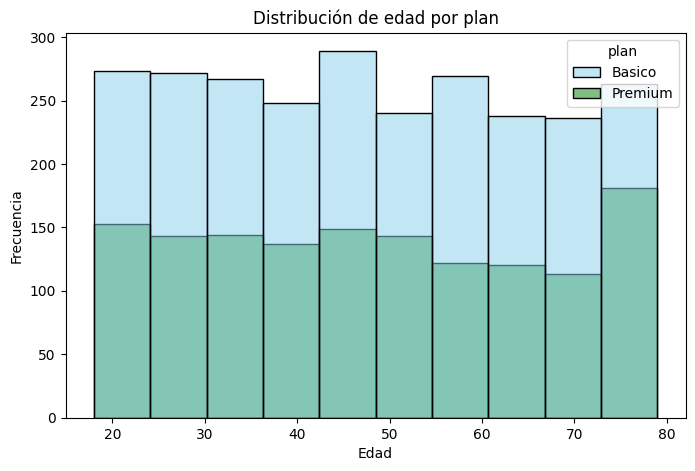

In [75]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8,5))
sns.histplot(data=user_profile, x='age', hue='plan', bins=10, palette=['skyblue','green'])

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: No hay gran diferencia entre planes, pero si Premium tiene usuarios ligeramente mayores, podría indicar mayor poder adquisitivo.
- Distribución Uniforme, no presenta sesgos pronunciados mas que un unico pico en las edades avanzadas

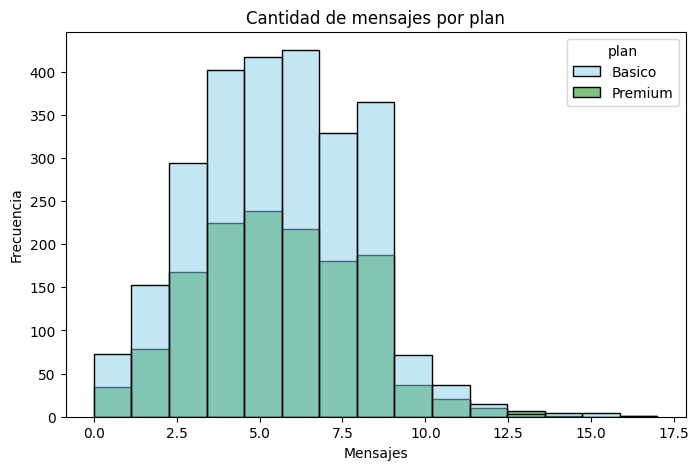

In [76]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=15, palette=['skyblue','green'])

plt.title('Cantidad de mensajes por plan')
plt.xlabel('Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: La distribucion de mensajes por plan representa un sesgo a la derecha , ya que la mayoria de los usuarios envia una cantidad moderada de mensajes, mientras que un grupo registra valores mas altos al resto.
- Distribucion con sesgo a la derecha.

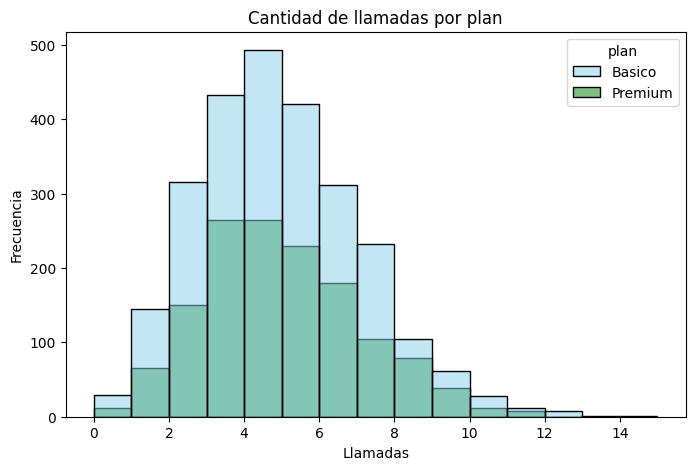

In [77]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=15, palette=['skyblue','green'])

plt.title('Cantidad de llamadas por plan')
plt.xlabel('Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: Se observa una distribucion normal/campana, concentrandose la mayoria entre 3 y 6 llamadas. Se observa un ligero sesgo a la derecha debido a usuarios con cantidades altas de llamadas. Ambos planes tiene un comportamiento similar. 
- Distribución de campana con un ligero sesgo a la derecha.

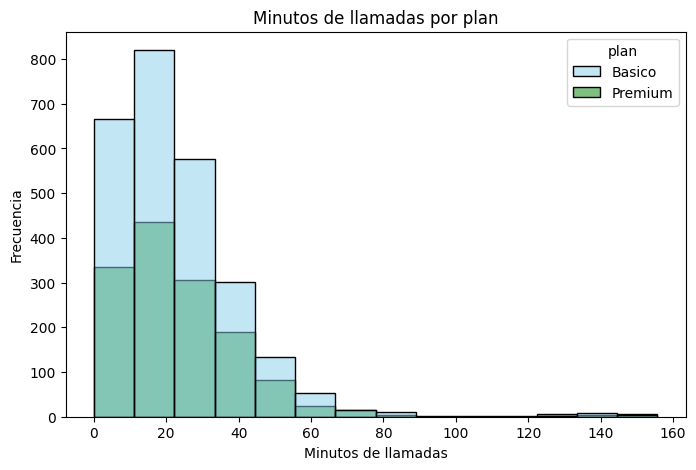

In [78]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=14, palette=['skyblue','green'])

plt.title('Minutos de llamadas por plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: La distribucion de minutos presenta un fuerte sesgo a la derecha, ya que la mayoria de usuarios realizan llamadas de pocos minutos, mientras que un grupo reducido acumula cantidades de minutos considerablemente altos, siendo estos posibles outliers o clientes whale
-Distribucion con sesgo a la derecha

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

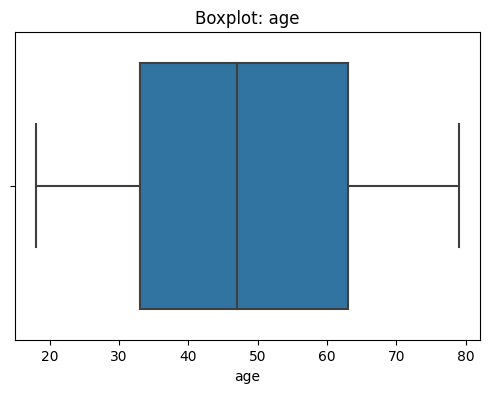

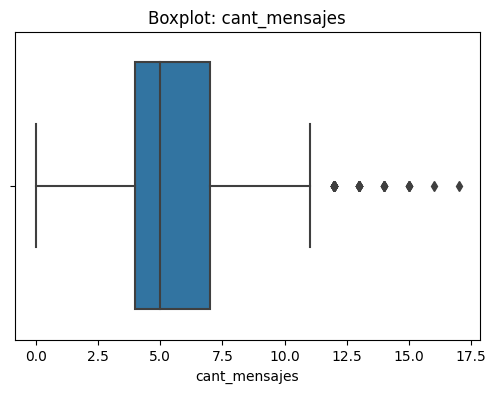

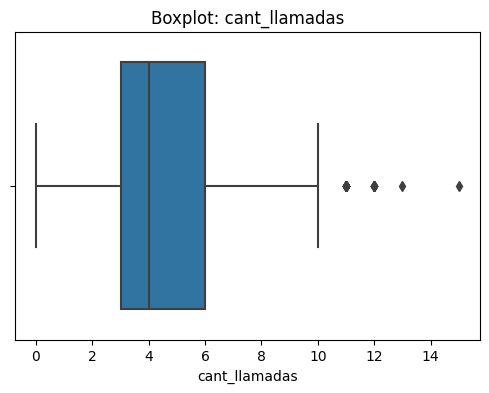

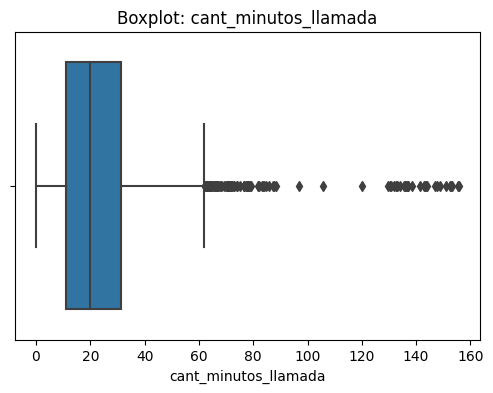

In [79]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers.
- cant_mensajes: presenta una distribucion asimetrica positiva, con algunos valores atipicos altos. La mayoria de usuarios envia una cantidad de mensajes moderada.
- cant_llamadas: presenta una distribucion con ligera asimetria positiva, indicando que algunos usuarios realizan muchas mas llamdas que la mayoria.
- cant_minutos_llamada: presenta una distribucion con una asimetria fuerte a la derecha, mostrando valores muy altos respecto a los demas, presentando posibles outliers, se tiene que revisar si son valores atipicos o errores de captura. 

In [87]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"\n{col}:")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Límite inferior: {limite_inferior:.2f}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print(f"  Valores máximos actuales: {user_profile[col].max():.2f}")


cant_mensajes:
  Q1: 4.00
  Q3: 7.00
  IQR: 3.00
  Límite inferior: -0.50
  Límite superior: 11.50
  Valores máximos actuales: 17.00

cant_llamadas:
  Q1: 3.00
  Q3: 6.00
  IQR: 3.00
  Límite inferior: -1.50
  Límite superior: 10.50
  Valores máximos actuales: 15.00

cant_minutos_llamada:
  Q1: 11.12
  Q3: 31.41
  IQR: 20.30
  Límite inferior: -19.32
  Límite superior: 61.86
  Valores máximos actuales: 155.69


In [89]:
user_profile['cant_minutos_llamada'].quantile(0.99)

82.19759999999998

In [88]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?  Se mantienen los datos actuales, ya que son valores atipicos pero pueden ser reales viendo que no se alejan mucho del limite superior.
- cant_llamadas: mantener o no outliers, porqué? Se mantienen los datos actuales, ya que como el caso anterior puden ser casos reales no muy alejados de el limite superior del IQR
- cant_minutos_llamada: mantener o no outliers, porqué? No se mantienen los outliers, ya que representan menos del 1% de los usuarios, se marcaria un limite para tener un mejor analisis y se investigaria mas esos datos especificos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [90]:
# Crear columna grupo_uso
def clasificar(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar, axis=1)

In [91]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [102]:

# Crear columna grupo_edad
def clasificar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [103]:
# verificar cambios
user_profile.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,5.0,7.0,44.97,Uso medio,Adulto Mayor
6,10006,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN,3.0,5.0,28.39,Uso medio,Adulto
7,10007,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN,3.0,5.0,30.23,Uso medio,Adulto Mayor
8,10008,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN,5.0,5.0,28.85,Uso medio,Adulto Mayor
9,10009,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN,5.0,3.0,5.99,Uso medio,Adulto


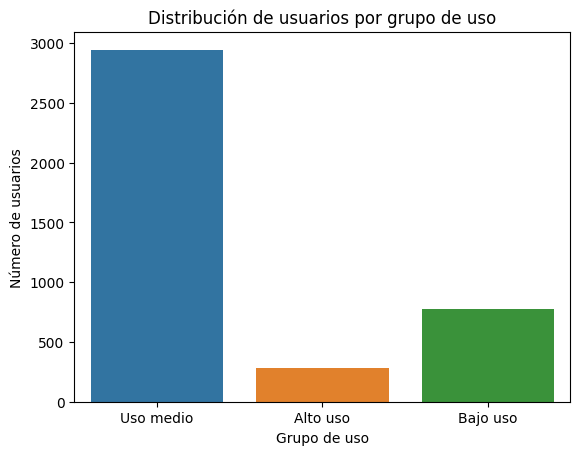

In [96]:
# Visualización de los segmentos por uso
sns.countplot(x='grupo_uso', data=user_profile)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')
plt.show()

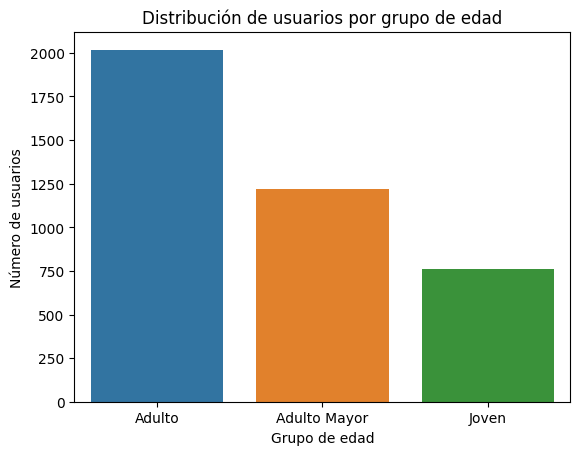

In [97]:
# Visualización de los segmentos por edad
sns.countplot(x='grupo_edad', data=user_profile)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
Durante la limpieza de los datos se identificaron valores nulos en las variables duration y length, pero estos estaban asociados a el tipo de uso, la columna type, esto represento un caso MAR. Tambien se encontraron valores atipicos como -999 en la columna Age, valores  "?" en la columna city y fechas futuras en la columna reg_date. 
Se encontro que la gran mayoria de los clientes se concentra en Adultos de entre los 30 y los 60 años, y el uso medio domina completamente sobre las otras categorias.
Se tiene presencia de un segmento valioso como los son los usuarios de uso alto que son los que tienen un potencial a planes premium, asi mismo los usuarios de la categoria Adultos que son la mayoria de los usuarios y poder destinar algun tipo de campaña a ese sector.
Se encontraron outliers en cant_mensajes, cant_llamadas y cant_minutos_llamada, en este ultimo fue el que tuvo outliers mayores que son posibles erroes de captura y podrian representar una distorcion al momento de realizar el analisis. 

Tomando en cuenta la distribucion de la edad de los usuarios, podria ser buena la implementacion de un plan intermedio entre los dos existentes, esta efocado en lo que es el sector de mayor numero de usuarios, un plan balanceado entre estos dos enfocado en el grupo Adultos.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores faltantes en variables clave como duration y length. En el caso de duration, los valores nulos dependían del tipo de uso (type), por lo que se clasificaron como datos MAR (Missing At Random)
- También se detectaron valores inválidos como -999 en age, "?" en city y fechas futuras en reg_date, los cuales fueron corregidos o convertidos en valores nulos para evitar sesgos en el análisis.


🔍 **Segmentos por Edad**
- Los usuarios adultos son el grupo de edad con mas cantidad de usuarios.
- El segmento de jovenes (< 30), son el grupo mas reducido, pero este es uno de los grupos con mayor potencial al ser un grupo con mayor uso de mensajes o llamadas. 


📊 **Segmentos por Nivel de Uso**
- Se identificaron tres grupos: bajo uso, uso medio y alto uso. La mayoría de usuarios se concentra en el uso medio de actividad.
- Los usuarios de alto uso representan un grupo reducido pero estratégico, ya que generan la mayor cantidad de minutos de llamadas y mensajes.


➡️ Esto sugiere que el comportamiento de los usuarios varía significativamente según la edad y el nivel de actividad. Los usuarios adultos y de alto uso representan oportunidades importantes para planes premium o servicios personalizados.


💡 **Recomendaciones**
- Diseñar planes diferentes según el comportamiento del usuario, ofreciendo opciones económicas para usuarios de bajo uso, paquetes ilimitados para usuarios intensivos o un plan intermedio para los usuarios que representan el mayor numero de actividad.
- implementar estrategias de retencion a los usuarios jovenes que tengan mayor uso, ya que representan el segmento con mayor potencial de crecimiento y generacion de impuestos. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`